In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/home/andis/projects/sphinxguard/ml/data/creditcard.csv')
print(df.shape)
print(df.head())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [2]:
print(f"Total transactions: {df.shape[0]}")
print(f"Fraudulent: {df['Class'].sum()}")
print(f"Legitimate: {df.shape[0] - df['Class'].sum()}")
print(f"Fraud percentage: {df['Class'].mean() * 100:.4f}%")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nAmount stats:")
print(df['Amount'].describe())

Total transactions: 284807
Fraudulent: 492
Legitimate: 284315
Fraud percentage: 0.1727%

Missing values: 0

Amount stats:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


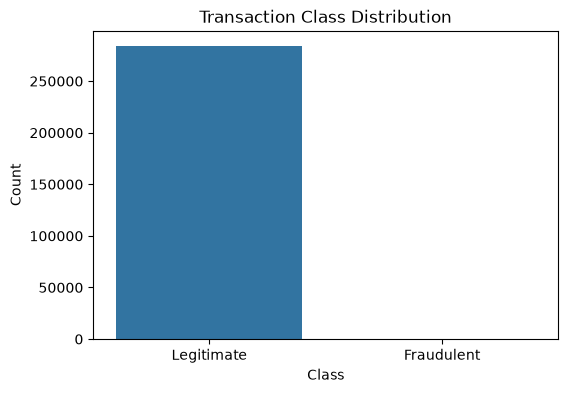

Class
0    284315
1       492
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Transaction Class Distribution')
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])
plt.ylabel('Count')
plt.show()

print(df['Class'].value_counts())

In [4]:
from sklearn.preprocessing import StandardScaler

# separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# scale Amount and Time (V1-V28 are already scaled from PCA)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

Features shape: (284807, 30)
Target shape: (284807,)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTraining fraud cases: {y_train.sum()}")
print(f"Test fraud cases: {y_test.sum()}")

Training set: (227845, 30)
Test set: (56962, 30)

Training fraud cases: 394
Test fraud cases: 98
